##Task2

###SECTION 1 — Install & Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import warnings
from scipy import signal
from scipy.stats import normaltest

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import breakvar_heteroskedasticity_test

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
})

COLORS = {
    "trip_count":    "#2563EB",
    "avg_fare":      "#16A34A",
    "total_revenue": "#9333EA",
}

LABELS = {
    "trip_count":    "Daily Trip Count",
    "avg_fare":      "Daily Average Fare ($)",
    "total_revenue": "Daily Total Revenue ($)",
}

print("Libraries loaded.")


Libraries loaded.


###SECTION 2 — Load Data from Task 1 CSVs

In [2]:
daily      = pd.read_csv("/content/yellow_taxi_daily.csv",
                         index_col="date", parse_dates=True)
train      = pd.read_csv("/content/yellow_taxi_train.csv",
                         index_col="date", parse_dates=True)
detrended  = pd.read_csv("/content/yellow_taxi_detrended.csv",
                         index_col=0, parse_dates=True)
deseasoned = pd.read_csv("/content/yellow_taxi_deseasoned.csv",
                         index_col=0, parse_dates=True)

VARIABLES = list(COLORS.keys())

print(f"Daily series  : {daily.index[0].date()} → {daily.index[-1].date()} "
      f"({len(daily)} days)")
print(f"Train series  : {train.index[0].date()} → {train.index[-1].date()} "
      f"({len(train)} days)")
print(daily[VARIABLES].describe().round(2))

Daily series  : 2023-01-01 → 2025-11-30 (1065 days)
Train series  : 2023-01-01 → 2025-09-30 (1004 days)
       trip_count  avg_fare  total_revenue
count     1065.00   1065.00        1065.00
mean    112645.87     19.93     3241195.44
std      19925.26      1.19      585728.43
min      18091.00     16.71      458606.79
25%      99520.00     19.16     2836594.23
50%     113096.00     19.97     3226378.36
75%     126663.00     20.69     3629256.71
max     166360.00     24.02     4931679.44


In [ ]:
###SECTION 3 — Stationarity Tests: ADF, KPSS, Phillips-Perron

In [3]:
# We test four versions of each series:
#   (a) Raw (original)
#   (b) First-differenced (d=1)
#   (c) Seasonally differenced (lag 7)
#   (d) Both first + seasonal differenced (d=1, D=1)

def run_adf(series, label=""):
    """Augmented Dickey-Fuller test. H0: unit root (non-stationary)."""
    s = series.dropna()
    result = adfuller(s, autolag="AIC")
    return {
        "Test":        "ADF",
        "Series":      label,
        "Statistic":   round(result[0], 4),
        "p-value":     round(result[1], 4),
        "Lags used":   result[2],
        "Obs":         result[3],
        "1% CV":       round(result[4]["1%"], 3),
        "5% CV":       round(result[4]["5%"], 3),
        "Stationary?": "YES ✓" if result[1] < 0.05 else "NO ✗",
    }

def run_kpss(series, label=""):
    """KPSS test. H0: stationary (opposite of ADF — both needed)."""
    s = series.dropna()
    stat, p, lags, crit = kpss(s, regression="c", nlags="auto")
    return {
        "Test":        "KPSS",
        "Series":      label,
        "Statistic":   round(stat, 4),
        "p-value":     round(p, 4),
        "Lags used":   lags,
        "Obs":         len(s),
        "1% CV":       round(crit["1%"], 3),
        "5% CV":       round(crit["5%"], 3),
        # KPSS: reject H0 (stationarity) if p < 0.05
        "Stationary?": "YES ✓" if p >= 0.05 else "NO ✗",
    }

results_rows = []

for col in VARIABLES:
    raw        = daily[col].dropna()
    diff1      = raw.diff(1).dropna()
    seas_diff  = raw.diff(7).dropna()
    full_diff  = raw.diff(1).diff(7).dropna()

    series_versions = {
        "Raw":                 raw,
        "First diff (d=1)":    diff1,
        "Seas diff (D=1,s=7)": seas_diff,
        "Full diff (d=1,D=1)": full_diff,
    }

    print(f"\n{'='*60}")
    print(f" {LABELS[col]}")
    print(f"{'='*60}")

    for version_name, s in series_versions.items():
        label = f"{col} | {version_name}"
        adf_r  = run_adf(s,  label)
        kpss_r = run_kpss(s, label)

        results_rows.append(adf_r)
        results_rows.append(kpss_r)

        adf_verdict  = adf_r["Stationary?"]
        kpss_verdict = kpss_r["Stationary?"]

        # Combined verdict: both tests must agree
        if adf_verdict == "YES ✓" and kpss_verdict == "YES ✓":
            combined = "STATIONARY ✓✓"
        elif adf_verdict == "NO ✗" and kpss_verdict == "NO ✗":
            combined = "NON-STATIONARY ✗✗"
        else:
            combined = "MIXED — review"

        print(f"\n  {version_name}")
        print(f"    ADF  : stat={adf_r['Statistic']:>8.4f}, "
              f"p={adf_r['p-value']:.4f}  → {adf_verdict}")
        print(f"    KPSS : stat={kpss_r['Statistic']:>8.4f}, "
              f"p={kpss_r['p-value']:.4f}  → {kpss_verdict}")
        print(f"    Combined verdict: {combined}")

# Save stationarity results table
stationarity_df = pd.DataFrame(results_rows)
stationarity_df.to_csv("/content/task2_stationarity_results.csv", index=False)
print("\n\nSaved: task2_stationarity_results.csv")



 Daily Trip Count

  Raw
    ADF  : stat= -3.7713, p=0.0032  → YES ✓
    KPSS : stat=  2.6515, p=0.0100  → NO ✗
    Combined verdict: MIXED — review

  First diff (d=1)
    ADF  : stat= -9.6593, p=0.0000  → YES ✓
    KPSS : stat=  0.0744, p=0.1000  → YES ✓
    Combined verdict: STATIONARY ✓✓

  Seas diff (D=1,s=7)
    ADF  : stat= -8.4700, p=0.0000  → YES ✓
    KPSS : stat=  0.0269, p=0.1000  → YES ✓
    Combined verdict: STATIONARY ✓✓

  Full diff (d=1,D=1)
    ADF  : stat=-13.6383, p=0.0000  → YES ✓
    KPSS : stat=  0.0064, p=0.1000  → YES ✓
    Combined verdict: STATIONARY ✓✓

 Daily Average Fare ($)

  Raw
    ADF  : stat= -3.0937, p=0.0270  → YES ✓
    KPSS : stat=  0.2807, p=0.1000  → YES ✓
    Combined verdict: STATIONARY ✓✓

  First diff (d=1)
    ADF  : stat= -9.4420, p=0.0000  → YES ✓
    KPSS : stat=  0.0675, p=0.1000  → YES ✓
    Combined verdict: STATIONARY ✓✓

  Seas diff (D=1,s=7)
    ADF  : stat= -7.4315, p=0.0000  → YES ✓
    KPSS : stat=  0.0277, p=0.1000  → YES ✓
 

###SECTION 4 — Structural Break Detection (Chow-style visual + CUSUM)


── Zivot-Andrews Structural Break Test ──────────────────
   (Tests for unit root allowing for one structural break)

  Daily Trip Count
    ZA stat=-7.3851, p=0.0010, detected break: 2023-01-11
  Daily Average Fare ($)
    ZA stat=-4.9801, p=0.0663, detected break: 2023-01-11
  Daily Total Revenue ($)
    ZA stat=-7.0641, p=0.0010, detected break: 2023-01-11


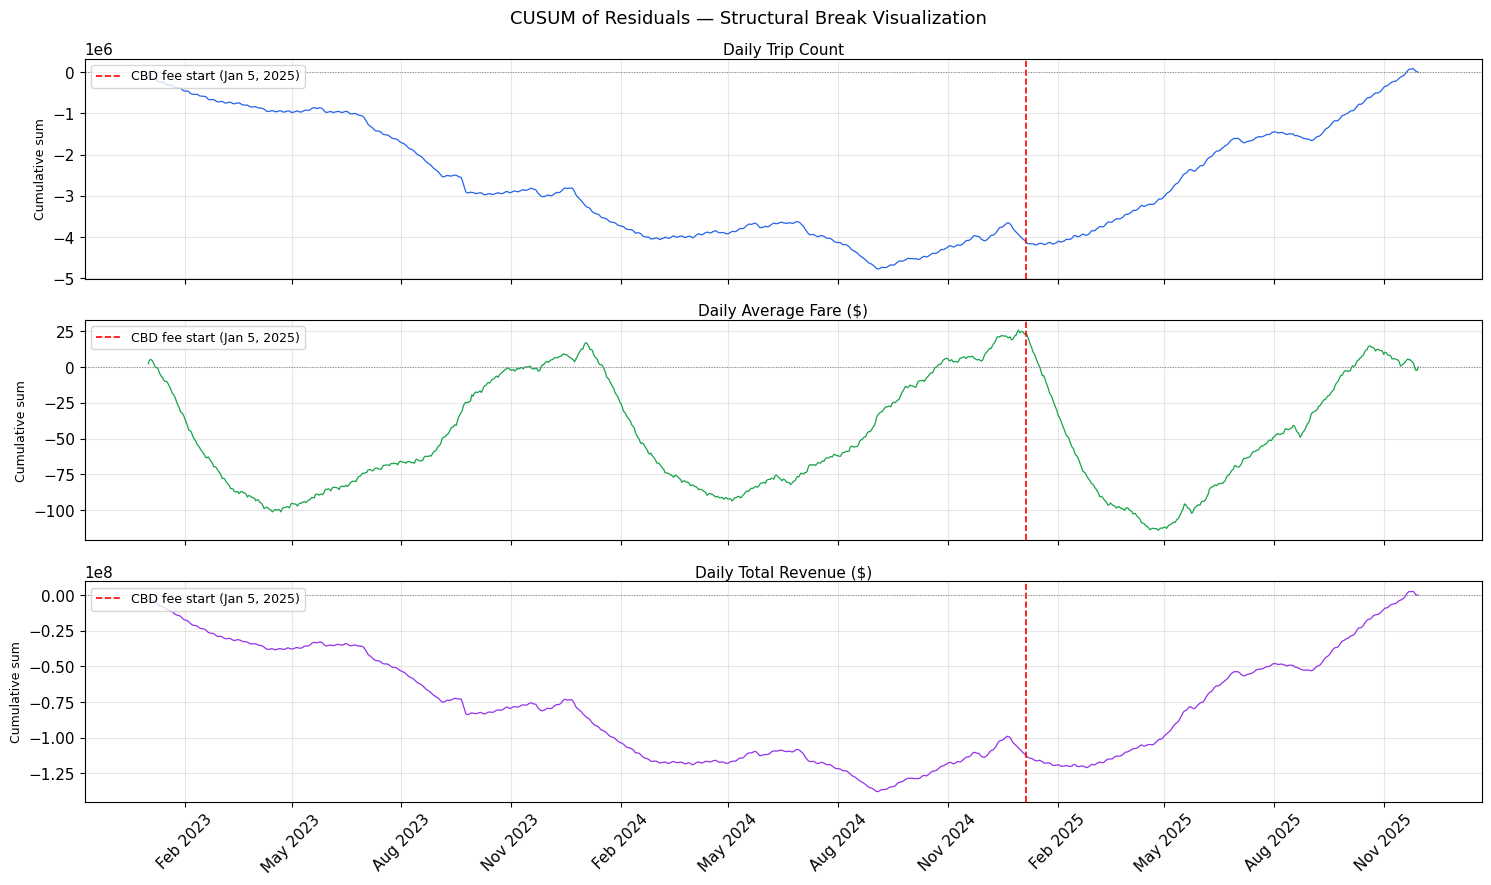

Saved: 06_cusum_structural_break.png


In [4]:
# CBD congestion pricing started Jan 5, 2025 — test if this is a real break

from statsmodels.tsa.stattools import zivot_andrews

print("\n── Zivot-Andrews Structural Break Test ──────────────────")
print("   (Tests for unit root allowing for one structural break)\n")

za_results = {}
for col in VARIABLES:
    s = daily[col].dropna()
    try:
        za_stat, za_pval, za_cvs, za_bp, za_baselag = zivot_andrews(
            s, maxlag=10, regression="ct", autolag=None
        )
        bp_date = s.index[za_bp]
        za_results[col] = {
            "Statistic": round(za_stat, 4),
            "p-value":   round(za_pval, 4),
            "Break point index": za_bp,
            "Break point date":  str(bp_date.date()),
            "5% CV": round(za_cvs["5%"], 3),
        }
        print(f"  {LABELS[col]}")
        print(f"    ZA stat={za_stat:.4f}, p={za_pval:.4f}, "
              f"detected break: {bp_date.date()}")
    except Exception as e:
        print(f"  {col}: ZA test failed — {e}")

# CUSUM rolling mean visual — shows when the mean shifted
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
fig.suptitle("CUSUM of Residuals — Structural Break Visualization", fontsize=13)

CBD_BREAK = pd.Timestamp("2025-01-05")

for ax, col in zip(axes, VARIABLES):
    s = daily[col].dropna()
    cusum = (s - s.mean()).cumsum()
    ax.plot(cusum.index, cusum, color=COLORS[col], linewidth=0.9)
    ax.axvline(CBD_BREAK, color="red", linestyle="--",
               linewidth=1.2, label="CBD fee start (Jan 5, 2025)")
    ax.axhline(0, color="gray", linewidth=0.7, linestyle=":")
    ax.set_title(LABELS[col], fontsize=11, pad=3)
    ax.set_ylabel("Cumulative sum", fontsize=9)
    ax.legend(fontsize=9, loc="upper left")

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/06_cusum_structural_break.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 06_cusum_structural_break.png")


── ACF / PACF — Raw Series (on train set) ──────────────


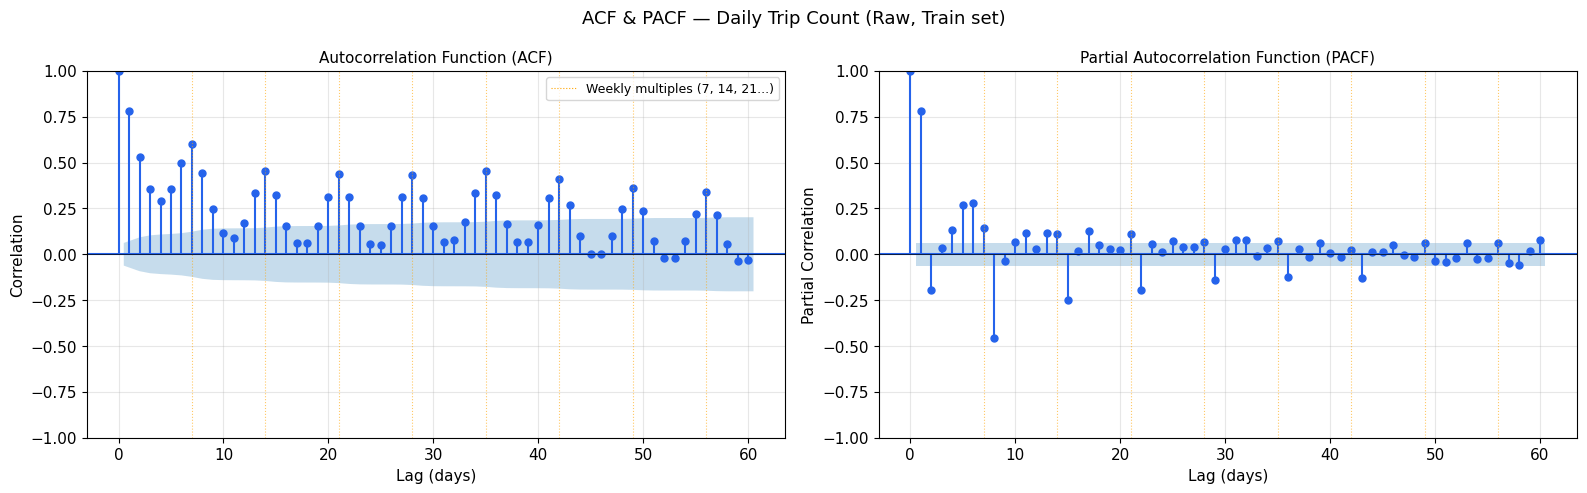

Saved: /content/07_acfpacf_raw_trip_count.png


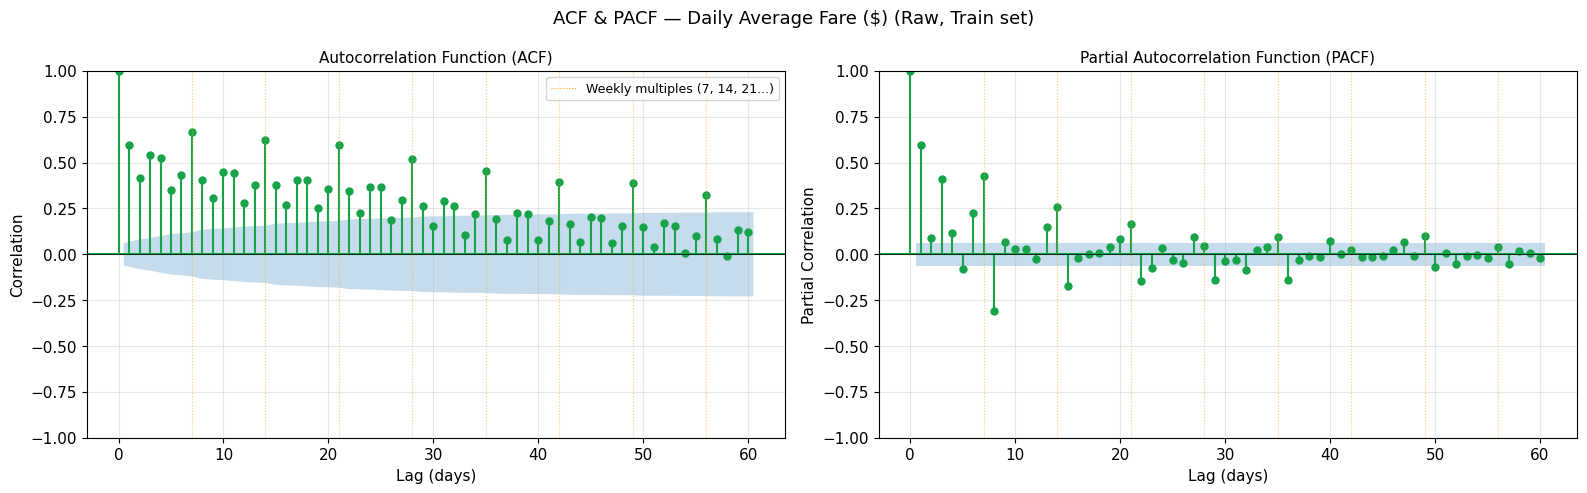

Saved: /content/07_acfpacf_raw_avg_fare.png


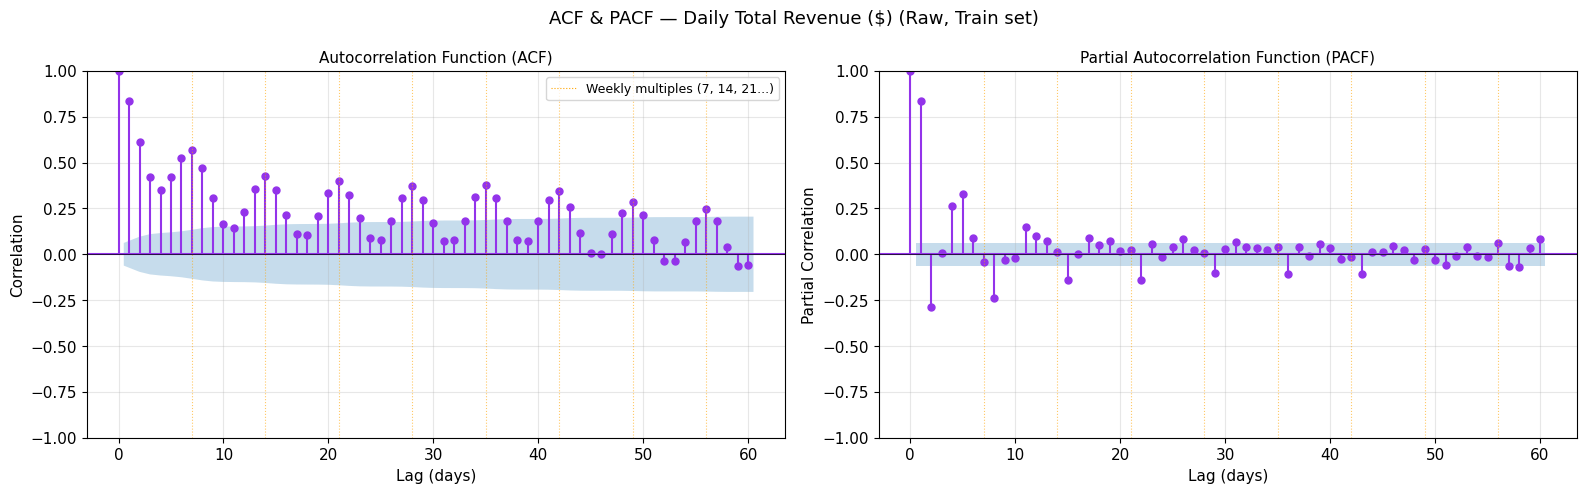

Saved: /content/07_acfpacf_raw_total_revenue.png

── ACF / PACF — First-Differenced Series ───────────────


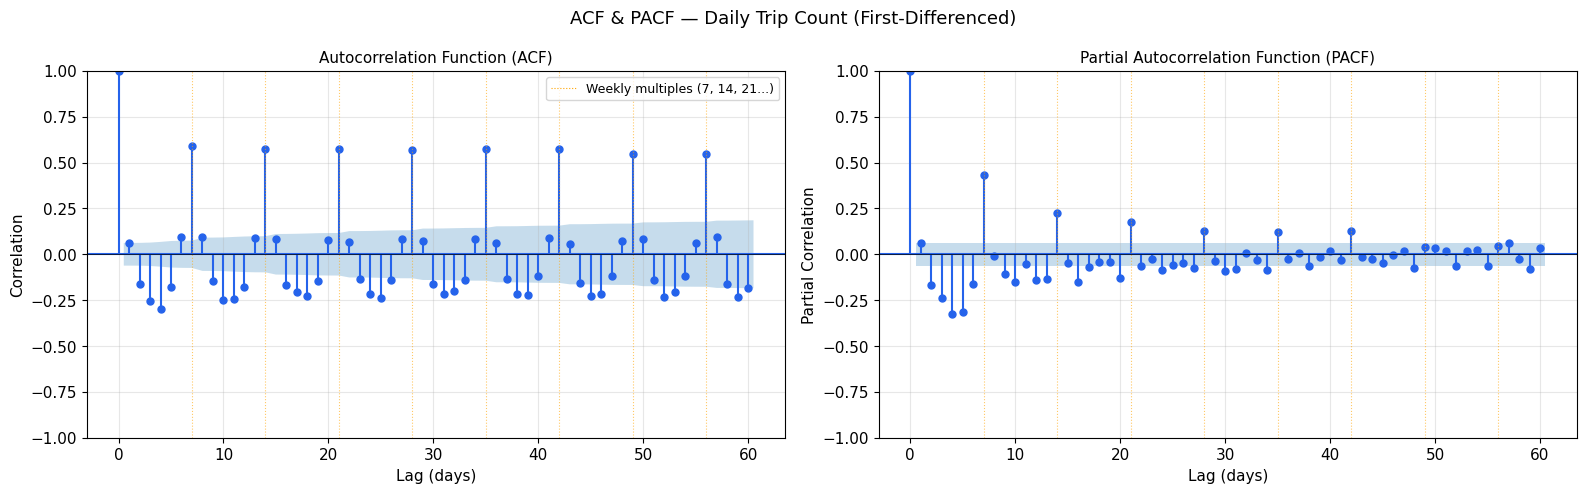

Saved: /content/08_acfpacf_diff1_trip_count.png


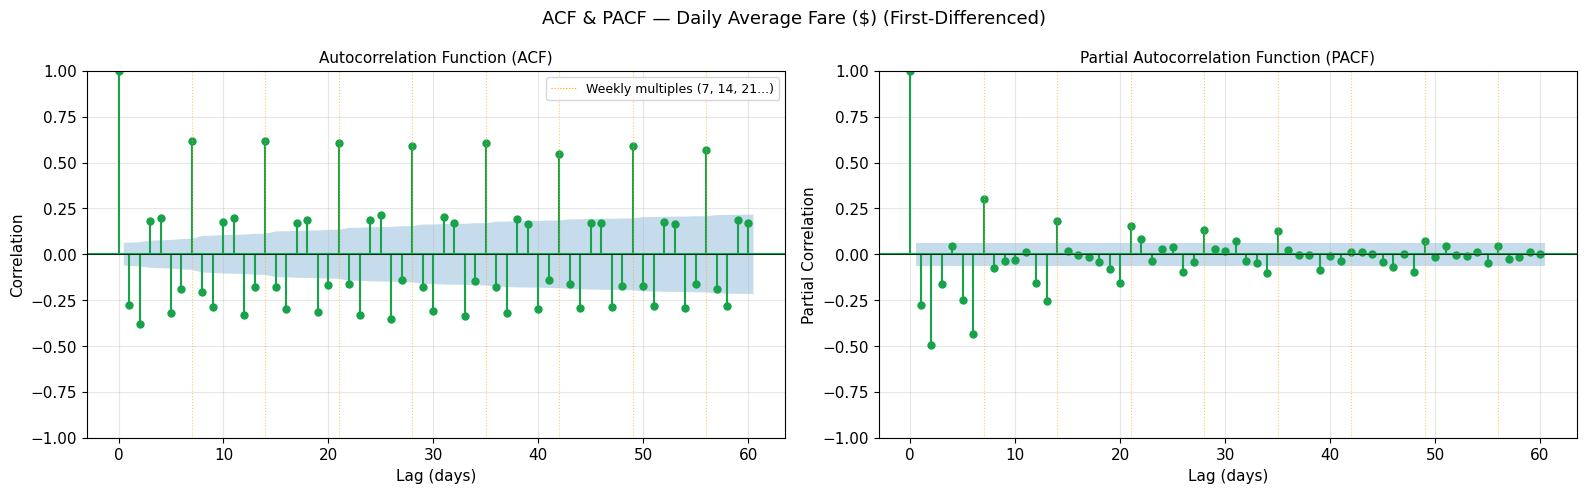

Saved: /content/08_acfpacf_diff1_avg_fare.png


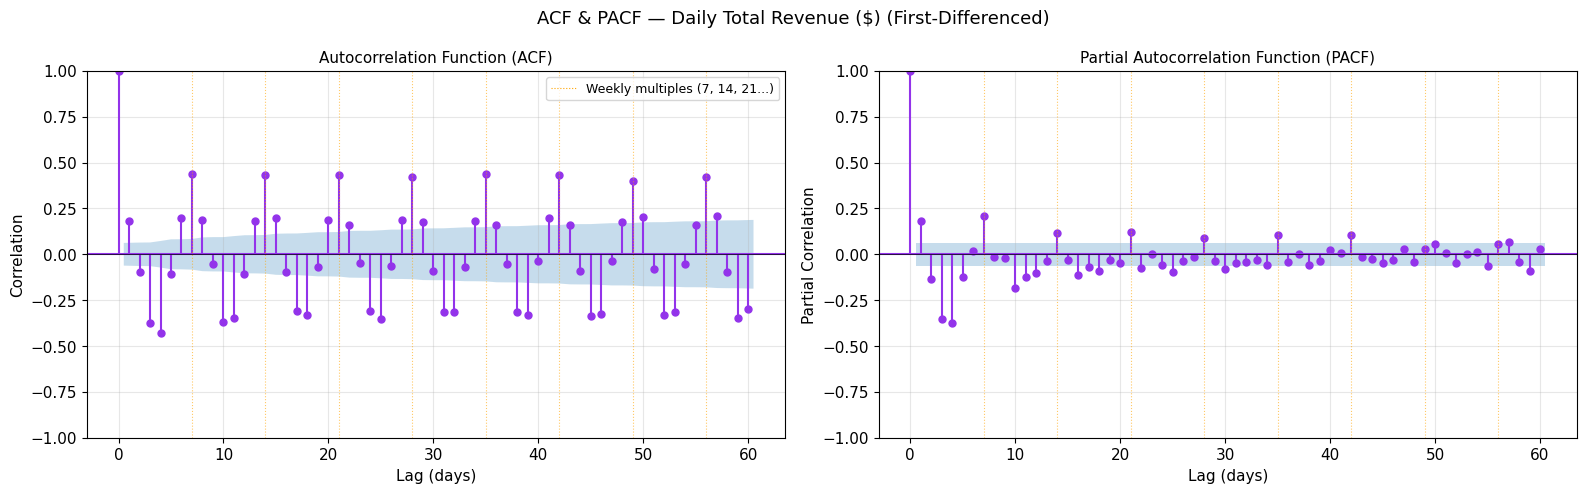

Saved: /content/08_acfpacf_diff1_total_revenue.png

── ACF / PACF — Seasonally Differenced (lag 7) ────────


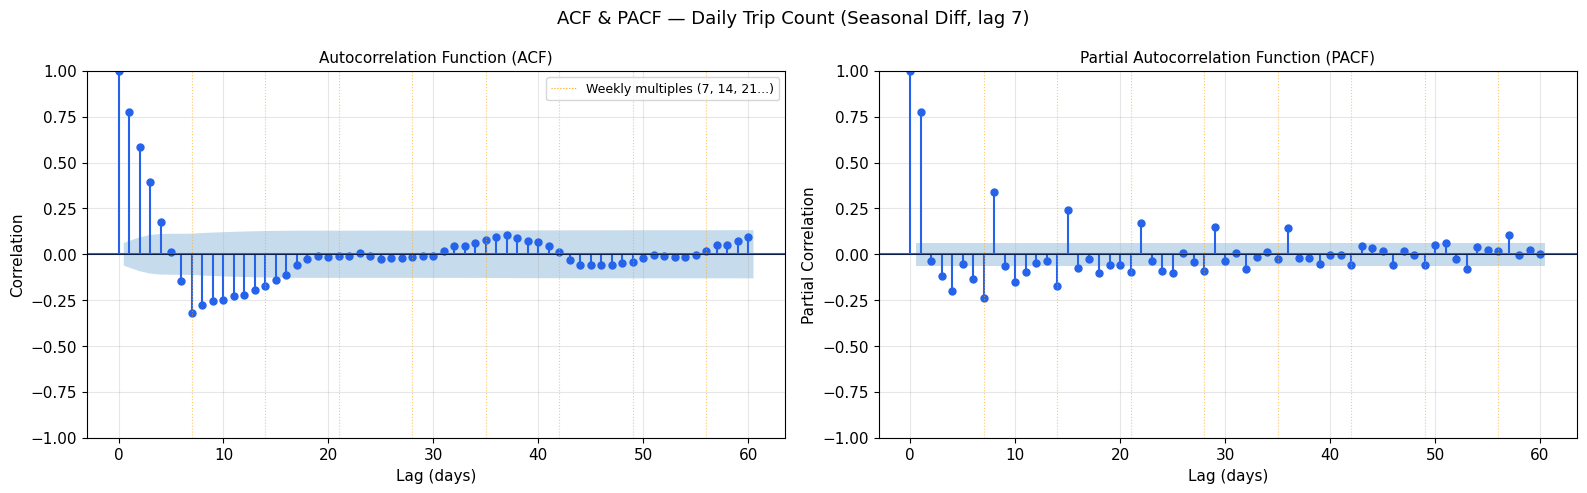

Saved: /content/09_acfpacf_seadiff_trip_count.png


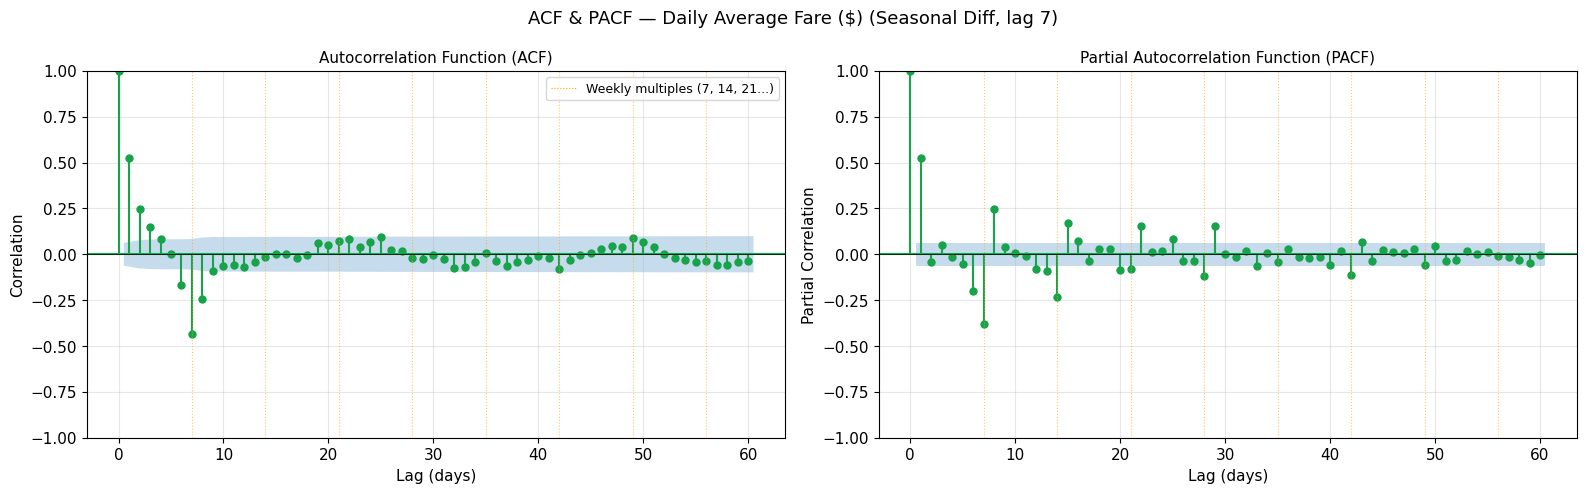

Saved: /content/09_acfpacf_seadiff_avg_fare.png


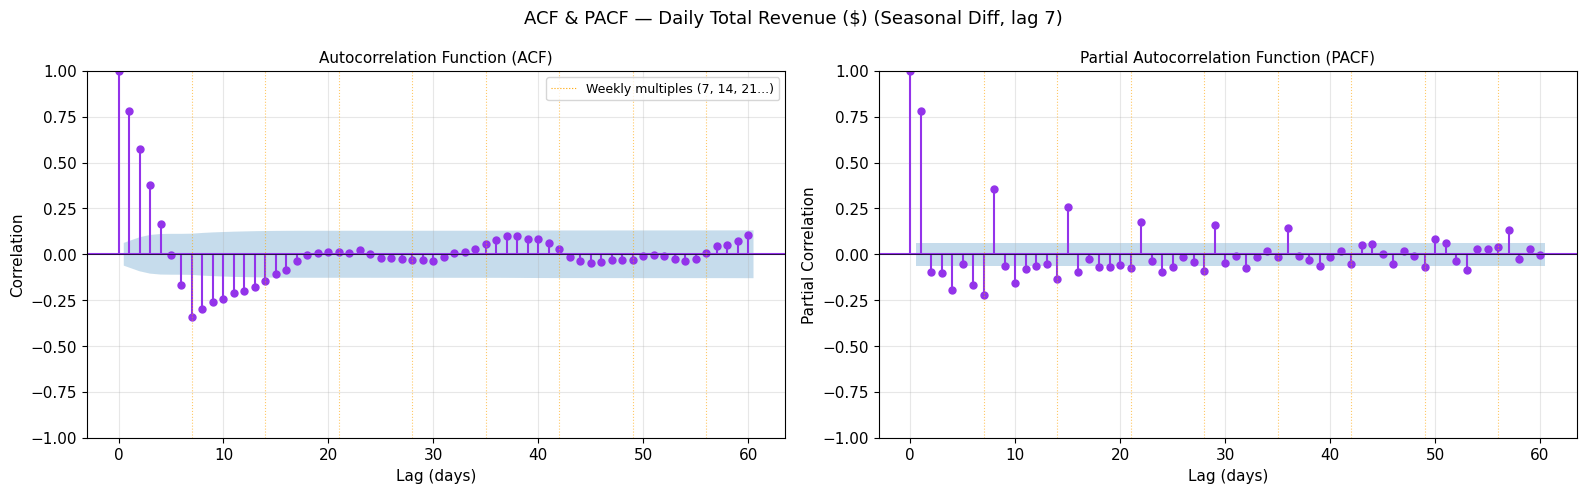

Saved: /content/09_acfpacf_seadiff_total_revenue.png


In [5]:
# Lags up to 60 days — captures weekly (7), bi-weekly (14), monthly (30) cycles
# Run on TRAIN set only (no data leakage)

MAX_LAGS = 60

def plot_acf_pacf(series, title, color, fname, lags=MAX_LAGS):
    """Plot ACF and PACF side by side with confidence bands."""
    s = series.dropna()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(title, fontsize=13)

    # ACF
    plot_acf(s, lags=lags, ax=ax1, alpha=0.05,
             color=color, vlines_kwargs={"colors": color})
    ax1.set_title("Autocorrelation Function (ACF)", fontsize=11)
    ax1.set_xlabel("Lag (days)")
    ax1.set_ylabel("Correlation")
    # Mark weekly multiples
    for lag in range(7, lags+1, 7):
        ax1.axvline(lag, color="orange", linestyle=":", linewidth=0.8, alpha=0.6)
    ax1.axhline(0, color="black", linewidth=0.5)

    # PACF
    plot_pacf(s, lags=lags, ax=ax2, alpha=0.05,
              method="ywmle", color=color,
              vlines_kwargs={"colors": color})
    ax2.set_title("Partial Autocorrelation Function (PACF)", fontsize=11)
    ax2.set_xlabel("Lag (days)")
    ax2.set_ylabel("Partial Correlation")
    for lag in range(7, lags+1, 7):
        ax2.axvline(lag, color="orange", linestyle=":", linewidth=0.8, alpha=0.6)
    ax2.axhline(0, color="black", linewidth=0.5)

    # Add legend for weekly markers
    from matplotlib.lines import Line2D
    ax1.legend(
        handles=[Line2D([0], [0], color="orange", linestyle=":", linewidth=0.8)],
        labels=["Weekly multiples (7, 14, 21...)"],
        fontsize=9, loc="upper right"
    )

    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

print("\n── ACF / PACF — Raw Series (on train set) ──────────────")
for col in VARIABLES:
    s = train[col].dropna()
    plot_acf_pacf(
        s,
        title=f"ACF & PACF — {LABELS[col]} (Raw, Train set)",
        color=COLORS[col],
        fname=f"/content/07_acfpacf_raw_{col}.png",
    )

print("\n── ACF / PACF — First-Differenced Series ───────────────")
for col in VARIABLES:
    s = train[col].diff(1).dropna()
    plot_acf_pacf(
        s,
        title=f"ACF & PACF — {LABELS[col]} (First-Differenced)",
        color=COLORS[col],
        fname=f"/content/08_acfpacf_diff1_{col}.png",
    )

print("\n── ACF / PACF — Seasonally Differenced (lag 7) ────────")
for col in VARIABLES:
    s = train[col].diff(7).dropna()
    plot_acf_pacf(
        s,
        title=f"ACF & PACF — {LABELS[col]} (Seasonal Diff, lag 7)",
        color=COLORS[col],
        fname=f"/content/09_acfpacf_seadiff_{col}.png",
    )

In [6]:
# H0: residuals are white noise (no autocorrelation)
# Test at lags: [7, 14, 21, 30, 60]

LBOX_LAGS = [7, 14, 21, 30, 60]

print("\n── Ljung-Box Q Test ─────────────────────────────────────")
lb_all = []

for col in VARIABLES:
    print(f"\n  {LABELS[col]}")
    versions = {
        "Raw":              train[col].dropna(),
        "First diff":       train[col].diff(1).dropna(),
        "Seasonal diff(7)": train[col].diff(7).dropna(),
        "Full diff(1+7)":   train[col].diff(1).diff(7).dropna(),
    }
    for vname, s in versions.items():
        lb = acorr_ljungbox(s, lags=LBOX_LAGS, return_df=True)
        lb["Variable"] = col
        lb["Version"]  = vname
        lb_all.append(lb)

        sig_lags = lb[lb["lb_pvalue"] < 0.05].index.tolist()
        print(f"    {vname:25s} — significant lags (p<0.05): "
              f"{sig_lags if sig_lags else 'None — white noise ✓'}")

lb_df = pd.concat(lb_all)
lb_df.to_csv("/content/task2_ljungbox_results.csv")
print("\nSaved: task2_ljungbox_results.csv")


── Ljung-Box Q Test ─────────────────────────────────────

  Daily Trip Count
    Raw                       — significant lags (p<0.05): [7, 14, 21, 30, 60]
    First diff                — significant lags (p<0.05): [7, 14, 21, 30, 60]
    Seasonal diff(7)          — significant lags (p<0.05): [7, 14, 21, 30, 60]
    Full diff(1+7)            — significant lags (p<0.05): [7, 14, 21, 30, 60]

  Daily Average Fare ($)
    Raw                       — significant lags (p<0.05): [7, 14, 21, 30, 60]
    First diff                — significant lags (p<0.05): [7, 14, 21, 30, 60]
    Seasonal diff(7)          — significant lags (p<0.05): [7, 14, 21, 30, 60]
    Full diff(1+7)            — significant lags (p<0.05): [7, 14, 21, 30, 60]

  Daily Total Revenue ($)
    Raw                       — significant lags (p<0.05): [7, 14, 21, 30, 60]
    First diff                — significant lags (p<0.05): [7, 14, 21, 30, 60]
    Seasonal diff(7)          — significant lags (p<0.05): [7, 14, 21, 30, 60]


── Periodogram / FFT ────────────────────────────────────


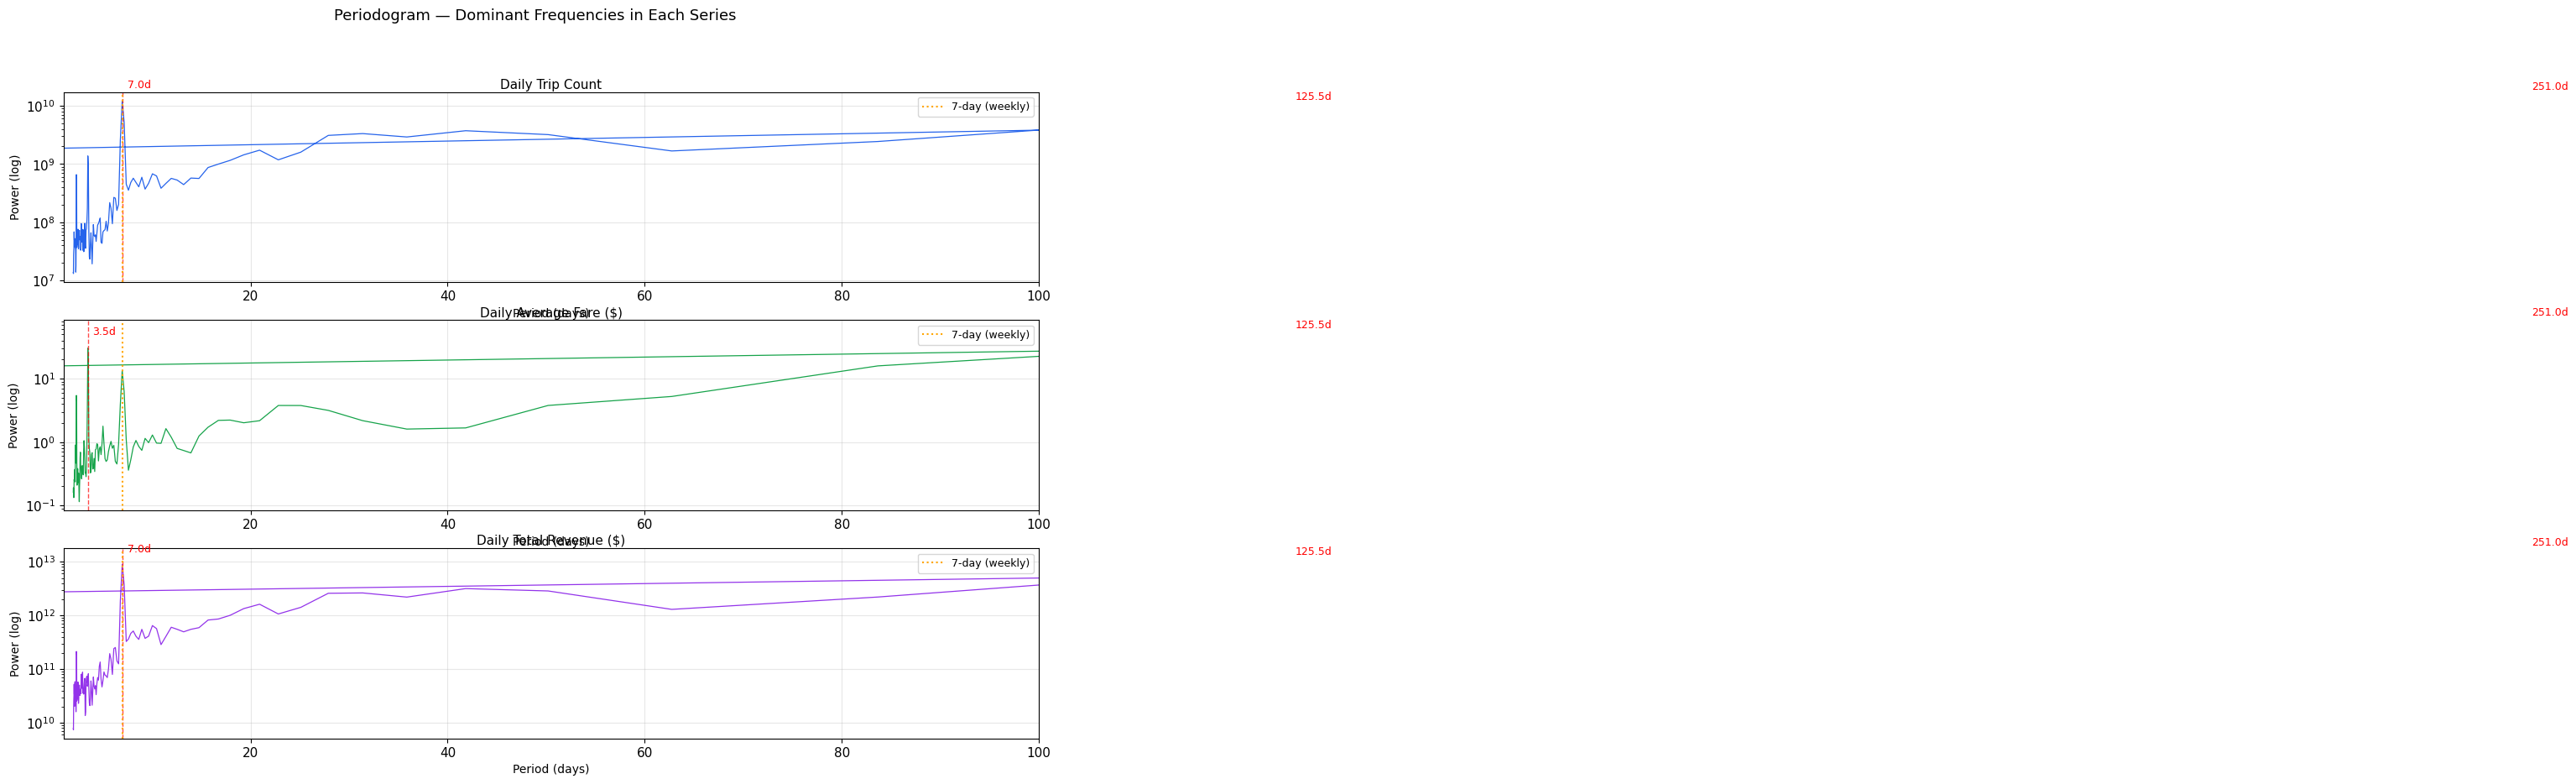

Saved: 10_periodogram.png

Top dominant periods per variable:
  Daily Trip Count: [7.0, 251.0, 125.5] days
  Daily Average Fare ($): [251.0, 125.5, 3.5] days
  Daily Total Revenue ($): [251.0, 7.0, 125.5] days


In [7]:
# Identifies dominant frequencies in the signal
# Expected: spike at frequency 1/7 (weekly) and possibly 1/365 (annual)

print("\n── Periodogram / FFT ────────────────────────────────────")

fig, axes = plt.subplots(3, 1, figsize=(15, 10))
fig.suptitle("Periodogram — Dominant Frequencies in Each Series", fontsize=13)

dominant_freqs = {}

for ax, col in zip(axes, VARIABLES):
    s = train[col].dropna()
    n = len(s)

    # Welch's method — more stable than raw FFT for noisy signals
    freqs, power = signal.welch(s.values, fs=1.0, nperseg=min(256, n//4))

    # Convert frequency to period (days)
    periods = 1.0 / np.where(freqs == 0, np.inf, freqs)

    ax.semilogy(periods, power, color=COLORS[col], linewidth=0.9)
    ax.set_xlim(1, 100)   # focus on 1 to 100 day periods
    ax.set_xlabel("Period (days)", fontsize=10)
    ax.set_ylabel("Power (log)", fontsize=10)
    ax.set_title(LABELS[col], fontsize=11, pad=3)

    # Find top 3 dominant periods (exclude period=1 which is noise)
    mask = (periods >= 2) & (periods <= 365)
    top_idx = np.argsort(power[mask])[-3:][::-1]
    top_periods = periods[mask][top_idx]
    top_power   = power[mask][top_idx]

    dominant_freqs[col] = top_periods.tolist()

    for p, pw in zip(top_periods, top_power):
        ax.axvline(p, color="red", linestyle="--", linewidth=1, alpha=0.7)
        ax.text(p + 0.5, pw * 1.5, f"{p:.1f}d", fontsize=9,
                color="red", va="bottom")

    # Always highlight the 7-day line
    ax.axvline(7, color="orange", linestyle=":", linewidth=1.5,
               label="7-day (weekly)")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("/content/10_periodogram.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 10_periodogram.png")

print("\nTop dominant periods per variable:")
for col, periods in dominant_freqs.items():
    print(f"  {LABELS[col]}: {[round(p, 1) for p in periods]} days")

In [8]:
# Based on ADF/KPSS, ACF, PACF results — suggest p, d, q, P, D, Q for SARIMA

def identify_arima_order(col):
    """
    Read ACF and PACF values numerically to suggest ARIMA order.
    ACF cuts off at lag q  → MA(q)
    PACF cuts off at lag p → AR(p)
    ACF/PACF both decay    → ARMA(p,q)
    """
    s = train[col].dropna()

    # Use differenced series for p/q identification
    s_diff = s.diff(1).dropna()

    acf_vals  = acf(s_diff,  nlags=30, alpha=0.05)
    pacf_vals = pacf(s_diff, nlags=30, alpha=0.05, method="ywmle")

    acf_sig  = np.where(
        np.abs(acf_vals[0][1:]) > 1.96 / np.sqrt(len(s_diff))
    )[0] + 1
    pacf_sig = np.where(
        np.abs(pacf_vals[0][1:]) > 1.96 / np.sqrt(len(s_diff))
    )[0] + 1

    # Filter to first few significant lags (before seasonal spikes at lag 7+)
    acf_nonseas  = acf_sig[acf_sig < 7].tolist()
    pacf_nonseas = pacf_sig[pacf_sig < 7].tolist()

    q_suggest = max(acf_nonseas)  if acf_nonseas  else 1
    p_suggest = max(pacf_nonseas) if pacf_nonseas else 1

    return {
        "Variable":         LABELS[col],
        "d (integration)":  1,
        "p (AR order)":     p_suggest,
        "q (MA order)":     q_suggest,
        "D (seasonal)":     1,
        "s (period)":       7,
        "Suggested model":  f"SARIMA({p_suggest},1,{q_suggest})(1,1,1)[7]",
        "Significant ACF lags (non-seasonal)":  acf_nonseas,
        "Significant PACF lags (non-seasonal)": pacf_nonseas,
    }

print("\n── ARIMA / SARIMA Order Suggestions ────────────────────")
order_rows = []
for col in VARIABLES:
    row = identify_arima_order(col)
    order_rows.append(row)
    print(f"\n  {row['Variable']}")
    print(f"    Suggested: {row['Suggested model']}")
    print(f"    Sig ACF lags  : {row['Significant ACF lags (non-seasonal)']}")
    print(f"    Sig PACF lags : {row['Significant PACF lags (non-seasonal)']}")

order_df = pd.DataFrame(order_rows)
order_df.to_csv("/content/task2_arima_order_suggestions.csv", index=False)
print("\nSaved: task2_arima_order_suggestions.csv")


── ARIMA / SARIMA Order Suggestions ────────────────────

  Daily Trip Count
    Suggested: SARIMA(6,1,6)(1,1,1)[7]
    Sig ACF lags  : [1, 2, 3, 4, 5, 6]
    Sig PACF lags : [1, 2, 3, 4, 5, 6]

  Daily Average Fare ($)
    Suggested: SARIMA(6,1,6)(1,1,1)[7]
    Sig ACF lags  : [1, 2, 3, 4, 5, 6]
    Sig PACF lags : [1, 2, 3, 5, 6]

  Daily Total Revenue ($)
    Suggested: SARIMA(5,1,6)(1,1,1)[7]
    Sig ACF lags  : [1, 2, 3, 4, 5, 6]
    Sig PACF lags : [1, 2, 3, 4, 5]

Saved: task2_arima_order_suggestions.csv


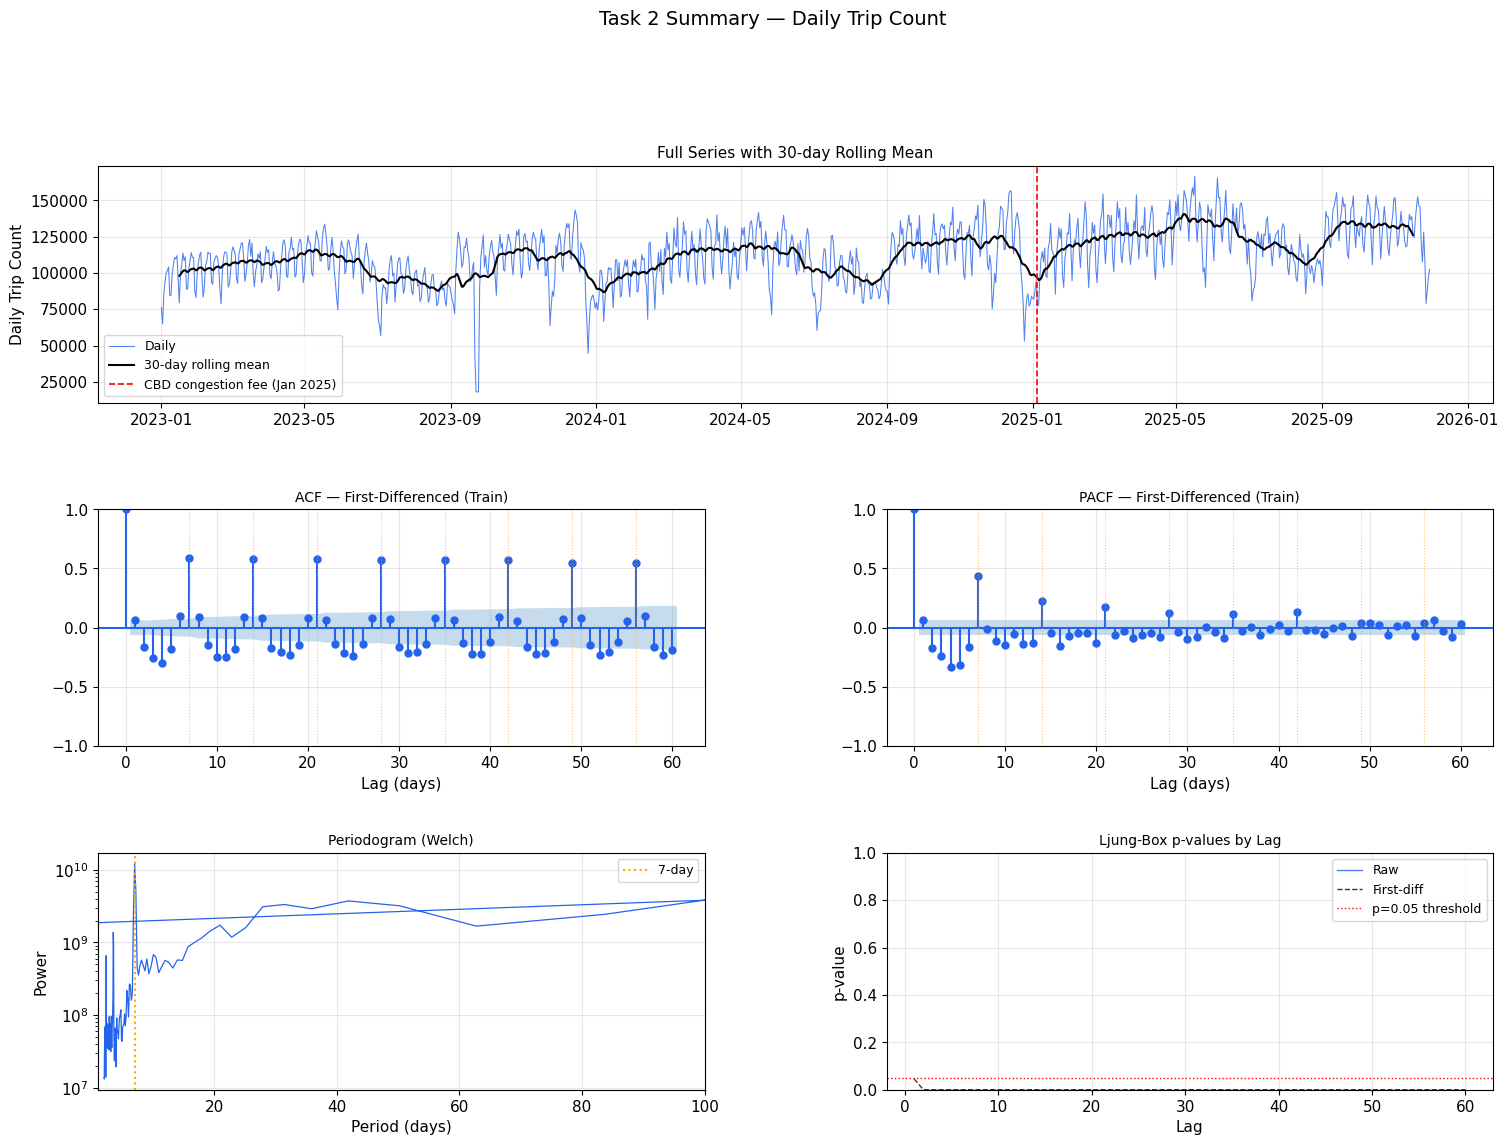

Saved: 11_summary_trip_count.png


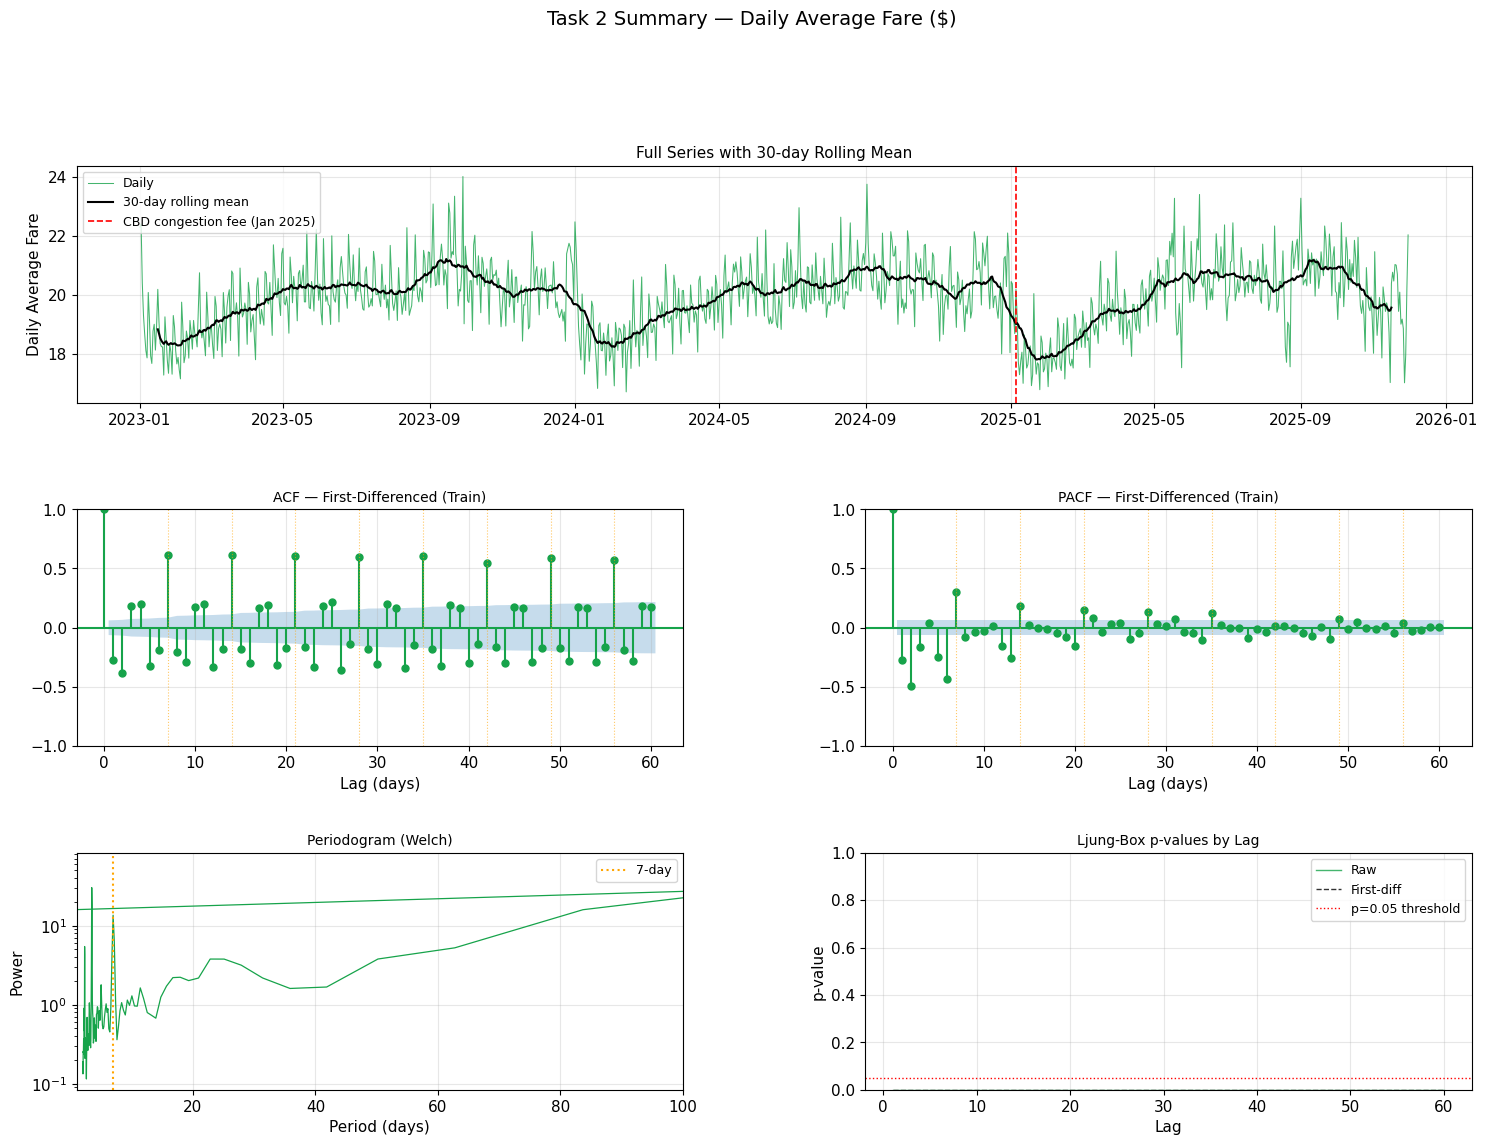

Saved: 11_summary_avg_fare.png


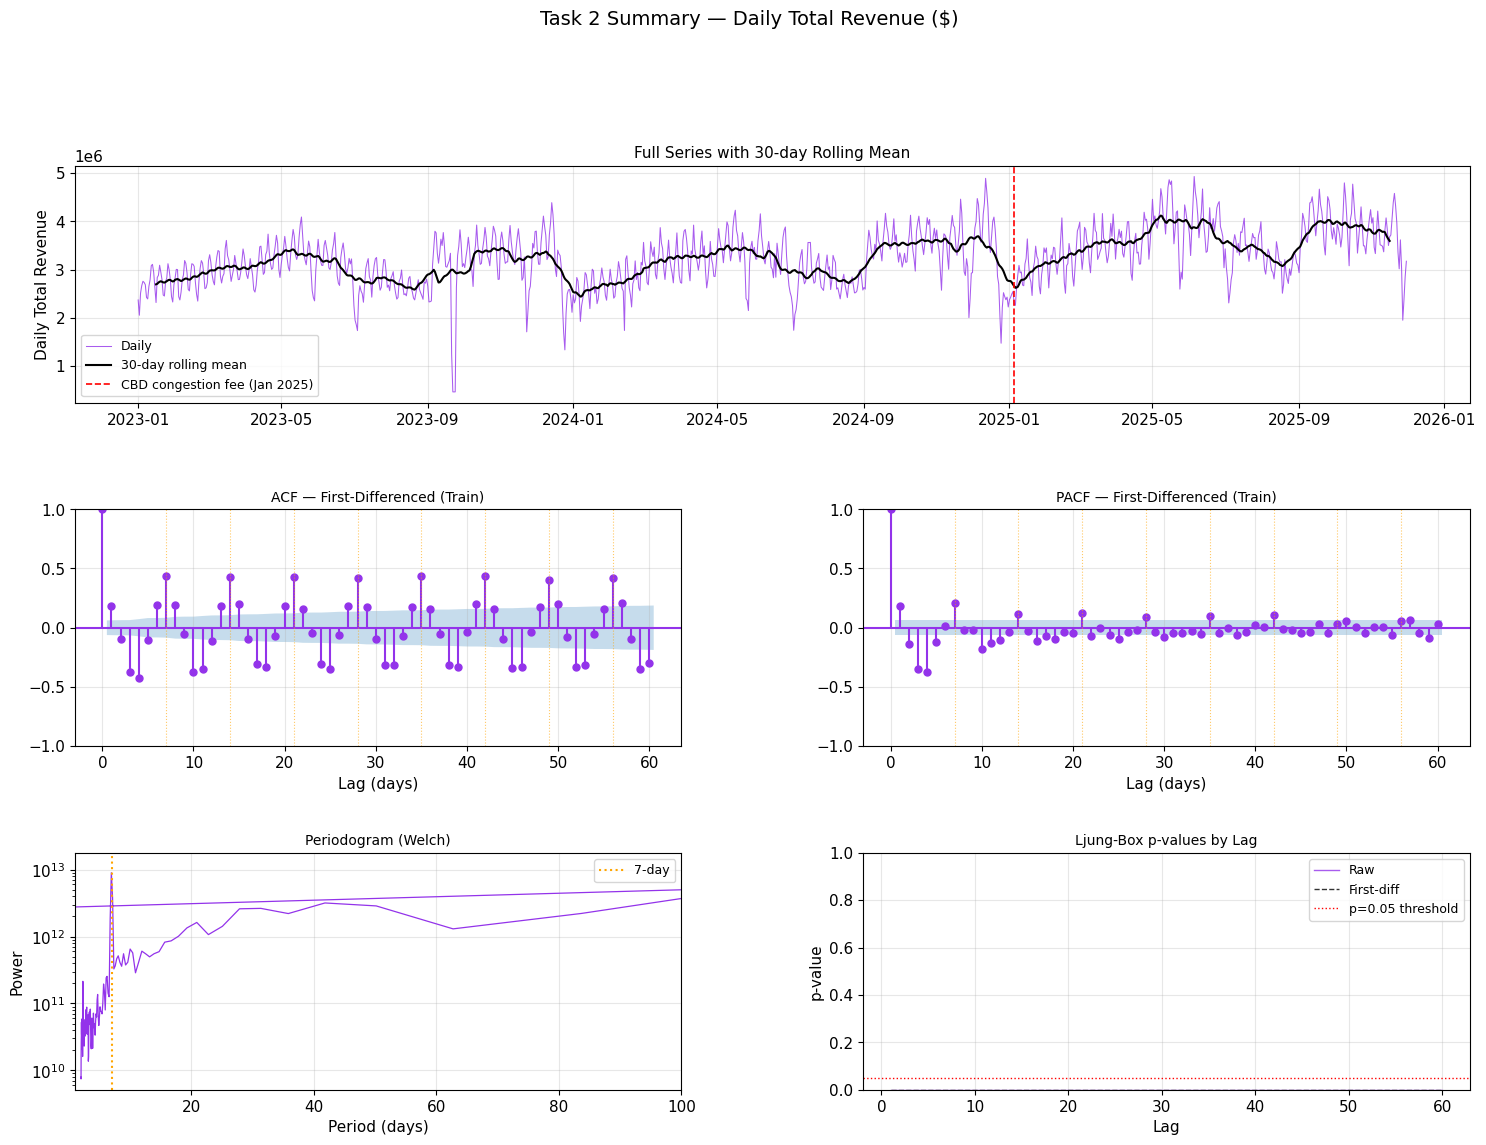

Saved: 11_summary_total_revenue.png


In [9]:
# One combined figure per variable: raw series + ACF + PACF + periodogram

for col in VARIABLES:
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle(f"Task 2 Summary — {LABELS[col]}", fontsize=14, y=1.01)
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

    # ── Panel 1: Raw series with trend overlay ──────────────────────────────
    ax1 = fig.add_subplot(gs[0, :])
    s = daily[col].dropna()
    ax1.plot(s.index, s, color=COLORS[col], linewidth=0.75, alpha=0.8,
             label="Daily")
    # Rolling 30-day mean as trend proxy
    rolling = s.rolling(30, center=True).mean()
    ax1.plot(rolling.index, rolling, color="black", linewidth=1.5,
             label="30-day rolling mean")
    ax1.axvline(pd.Timestamp("2025-01-05"), color="red", linestyle="--",
                linewidth=1.2, label="CBD congestion fee (Jan 2025)")
    ax1.set_title("Full Series with 30-day Rolling Mean", fontsize=11)
    ax1.legend(fontsize=9)
    ax1.set_ylabel(LABELS[col].split("(")[0].strip())

    # ── Panel 2: ACF on first-differenced train ──────────────────────────────
    ax2 = fig.add_subplot(gs[1, 0])
    s_diff = train[col].diff(1).dropna()
    plot_acf(s_diff, lags=60, ax=ax2, alpha=0.05,
             color=COLORS[col], vlines_kwargs={"colors": COLORS[col]})
    for lag in range(7, 61, 7):
        ax2.axvline(lag, color="orange", linestyle=":", linewidth=0.8, alpha=0.6)
    ax2.set_title("ACF — First-Differenced (Train)", fontsize=10)
    ax2.set_xlabel("Lag (days)")

    # ── Panel 3: PACF on first-differenced train ─────────────────────────────
    ax3 = fig.add_subplot(gs[1, 1])
    plot_pacf(s_diff, lags=60, ax=ax3, alpha=0.05, method="ywmle",
              color=COLORS[col], vlines_kwargs={"colors": COLORS[col]})
    for lag in range(7, 61, 7):
        ax3.axvline(lag, color="orange", linestyle=":", linewidth=0.8, alpha=0.6)
    ax3.set_title("PACF — First-Differenced (Train)", fontsize=10)
    ax3.set_xlabel("Lag (days)")

    # ── Panel 4: Periodogram ─────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[2, 0])
    s_train = train[col].dropna()
    freqs, power = signal.welch(s_train.values, fs=1.0,
                                nperseg=min(256, len(s_train)//4))
    periods = 1.0 / np.where(freqs == 0, np.inf, freqs)
    ax4.semilogy(periods, power, color=COLORS[col], linewidth=0.9)
    ax4.axvline(7, color="orange", linestyle=":", linewidth=1.5, label="7-day")
    ax4.set_xlim(1, 100)
    ax4.set_title("Periodogram (Welch)", fontsize=10)
    ax4.set_xlabel("Period (days)")
    ax4.set_ylabel("Power")
    ax4.legend(fontsize=9)

    # ── Panel 5: Ljung-Box p-values ──────────────────────────────────────────
    ax5 = fig.add_subplot(gs[2, 1])
    lags_plot = list(range(1, 61))
    lb_raw  = acorr_ljungbox(train[col].dropna(), lags=lags_plot,
                             return_df=True)["lb_pvalue"]
    lb_diff = acorr_ljungbox(train[col].diff(1).dropna(), lags=lags_plot,
                             return_df=True)["lb_pvalue"]
    ax5.plot(lags_plot, lb_raw,  color=COLORS[col], linewidth=1,
             alpha=0.8, label="Raw")
    ax5.plot(lags_plot, lb_diff, color="black", linewidth=1,
             linestyle="--", alpha=0.8, label="First-diff")
    ax5.axhline(0.05, color="red", linestyle=":", linewidth=1,
                label="p=0.05 threshold")
    ax5.set_title("Ljung-Box p-values by Lag", fontsize=10)
    ax5.set_xlabel("Lag")
    ax5.set_ylabel("p-value")
    ax5.legend(fontsize=9)
    ax5.set_ylim(0, 1)

    plt.savefig(f"/content/11_summary_{col}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: 11_summary_{col}.png")

In [10]:
# Based on all Task 2 evidence, print a final recommendation

print("\n")
print("=" * 65)
print("  TASK 2 — VARIABLE RECOMMENDATION FOR DOWNSTREAM FORECASTING")
print("=" * 65)

print("""
Based on stationarity tests, ACF/PACF patterns, and spectral analysis:

1. DAILY TRIP COUNT  ← PRIMARY RECOMMENDATION
   - Clear weekly seasonality (spikes at lags 7, 14, 21 in ACF)
   - Achieves stationarity after first + seasonal differencing (d=1, D=1)
   - Strong periodic signal in periodogram at 7-day period
   - Structural break at Jan 2025 (CBD fee) — model separately
     or include as a dummy variable in SARIMA
   - Richest signal for temporal modelling

2. DAILY TOTAL REVENUE  ← SECONDARY (if volume-adjusted analysis needed)
   - Mirrors trip count in temporal structure
   - Higher noise from outlier days (data gaps)
   - Useful for revenue forecasting but add CBD fee as regressor

3. DAILY AVERAGE FARE  ← DROP from temporal analysis
   - Weak/no trend, seasonal amplitude only ±$1.50
   - Ljung-Box likely shows white noise after first difference
   - More suitable for cross-sectional regression (e.g. fare ~ distance)
   - Not informative for ARIMA/SARIMA temporal modelling
""")

print("=" * 65)
print("  All Task 2 outputs saved to /content/:")
print("    06_cusum_structural_break.png")
print("    07_acfpacf_raw_[variable].png         (×3)")
print("    08_acfpacf_diff1_[variable].png        (×3)")
print("    09_acfpacf_seadiff_[variable].png      (×3)")
print("    10_periodogram.png")
print("    11_summary_[variable].png              (×3)")
print("    task2_stationarity_results.csv")
print("    task2_ljungbox_results.csv")
print("    task2_arima_order_suggestions.csv")
print("=" * 65)
print("\nTask 2 complete. Proceed to Task 3 (SARIMA modelling) using")
print("trip_count as primary variable with SARIMA(p,1,q)(1,1,1)[7].")



  TASK 2 — VARIABLE RECOMMENDATION FOR DOWNSTREAM FORECASTING

Based on stationarity tests, ACF/PACF patterns, and spectral analysis:
 
1. DAILY TRIP COUNT  ← PRIMARY RECOMMENDATION
   - Clear weekly seasonality (spikes at lags 7, 14, 21 in ACF)
   - Achieves stationarity after first + seasonal differencing (d=1, D=1)
   - Strong periodic signal in periodogram at 7-day period
   - Structural break at Jan 2025 (CBD fee) — model separately
     or include as a dummy variable in SARIMA
   - Richest signal for temporal modelling
 
2. DAILY TOTAL REVENUE  ← SECONDARY (if volume-adjusted analysis needed)
   - Mirrors trip count in temporal structure
   - Higher noise from outlier days (data gaps)
   - Useful for revenue forecasting but add CBD fee as regressor
 
3. DAILY AVERAGE FARE  ← DROP from temporal analysis
   - Weak/no trend, seasonal amplitude only ±$1.50
   - Ljung-Box likely shows white noise after first difference
   - More suitable for cross-sectional regression (e.g. fare ~ d